# Exp 04 — mT5-small + LoRA (attention targets, r=16)

**Model context.** LoRA rank raised to 16 on the attention projections. First strong leaderboard score; reveals the lexical-overlap vs fluency gap.

*Multilingual Health QA in Low-Resource African Languages — fine-tuning experiment 04.*

## Install dependencies
Pin `peft` to a compatible build and install only the packages not already present, without upgrading the pre-installed PyTorch (this keeps the CUDA build matched to the GPU). If `get_peft_model` raises a torchao error, restart the kernel once and run from the top.

In [1]:
# Pin peft to a build that does NOT require torchao>=0.16.
# We don't use torchao — it's only pulled in by a version check inside newer peft.
!pip install -q "peft==0.14.0" transformers datasets accelerate rouge-score

# If Kaggle had already imported peft/torch this session, restart the kernel once
# (Run > Restart & clear cell outputs) after this install, then run from the top.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.8/374.8 kB 7.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 91.7 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompa

## the platform paths (no Drive mount)

In [4]:
# Kaggle: CSVs come from the uploaded Dataset; outputs go to /kaggle/working/.
DATA_DIR = '/kaggle/input/datasets/miraclenanenmbanaade/multilingual-health-qa/'
SAVE_DIR = '/kaggle/working/outputs/'
CKPT_DIR = '/kaggle/working/checkpoints/exp04/'

import os
for d in [SAVE_DIR, CKPT_DIR]:
    os.makedirs(d, exist_ok=True)

# Sanity check — confirm the CSVs are where we expect.
print('Files in DATA_DIR:', os.listdir(DATA_DIR))

Files in DATA_DIR: ['Val.csv', 'Train.csv', 'Test.csv']


## Imports and seed

In [5]:
import random, re, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from tqdm.notebook import tqdm
from rouge_score import rouge_scorer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


## Load data

In [6]:
train_df = pd.read_csv(DATA_DIR + 'Train.csv')
val_df   = pd.read_csv(DATA_DIR + 'Val.csv')
test_df  = pd.read_csv(DATA_DIR + 'Test.csv')

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

Train: 29815 | Val: 6686 | Test: 2618


## Parse language and country from `subset`

In [7]:
SUBSET_MAP = {
    'Aka_Gha': ('Akan',    'Ghana'),
    'Amh_Eth': ('Amharic', 'Ethiopia'),
    'Lug_Uga': ('Luganda', 'Uganda'),
    'Swa_Ken': ('Swahili', 'Kenya'),
    'Swa_Tan': ('Swahili', 'Tanzania'),
    'Swa_Uga': ('Swahili', 'Uganda'),
    'Eng_Gha': ('English', 'Ghana'),
    'Eng_Uga': ('English', 'Uganda'),
    'Eng_Ken': ('English', 'Kenya'),
}

for df in [train_df, val_df, test_df]:
    df['language'] = df['subset'].map(lambda s: SUBSET_MAP.get(s, (s, ''))[0])
    df['country']  = df['subset'].map(lambda s: SUBSET_MAP.get(s, ('', s))[1])

print(train_df[['subset','language','country']].drop_duplicates().sort_values('subset').to_string(index=False))

 subset language  country
Aka_Gha     Akan    Ghana
Amh_Eth  Amharic Ethiopia
Eng_Eth  Eng_Eth  Eng_Eth
Eng_Gha  English    Ghana
Eng_Ken  English    Kenya
Eng_Uga  English   Uganda
Lug_Uga  Luganda   Uganda
Swa_Ken  Swahili    Kenya


## Clean text and build prompts

In [8]:
def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = re.sub(r'[\r\n\t]+', ' ', text)
    return re.sub(r' {2,}', ' ', text).strip()

def build_prompt(question, language, country=''):
    header = f'Language: {language}'
    if country:
        header += f' | Country: {country}'
    return f'{header}\nQuestion: {question}\nAnswer:'

for df in [train_df, val_df, test_df]:
    df['input_clean'] = df['input'].apply(clean_text)
    df['prompt_text'] = df.apply(
        lambda r: build_prompt(r['input_clean'], r['language'], r['country']), axis=1
    )

for df in [train_df, val_df]:
    df['output_clean'] = df['output'].apply(clean_text)

print(train_df['prompt_text'].iloc[0])
print()
print(train_df['output_clean'].iloc[0])

Language: Akan | Country: Ghana
Question: Ɔkwan bɛn so na mmabunbɛtumi aboa wɔn mfɛfoɔ a nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ? Yei bi ne sɛnea wɔbɛkyekye wɔn werɛ, sɛnea wɔbɛboa wɔn ma wɔanya mmoa firi nnwumakuo a ɛfata hɔ, ne sɛnea wɔbɛsiw afɔbu suban ne nsɛm a nkurɔfoɔ de gu oyarefoɔ no so no kwan.
Answer:

Mmabun betumi aboa atipɛnfo a ebia nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ so denam: Nkate fam mmoa a wɔde bɛma na wɔagye wɔn nkate atom a wɔremmu atɛn anaasɛ wɔmfa asodi nto wɔn so. Wɔn a wɔbɛhyɛ wɔn nkuran ma wɔakɔhwehwɛ ayaresa na wɔanya mmoa nnwuma te sɛ afotu, telefon a wɔde frɛ nkurɔfo wɔ ɔhaw mu, anaa ahyehyɛde ahorow a wɔkamfo nkurɔfo. Boa a wɔbɛboa wɔn ma wɔafa akwan horow a wɔbɛfa so abɔ amanneɛ, a nea ɛka ho ne sɛ wɔbɛkɔ mmarahyɛ baguafo nkyɛn anaasɛ wɔbɛhwehwɛ mmara kwan so mmoa sɛ wɔpɛ sɛ wɔde mmara kwan so asɛm bɛkɔ atia nea ɔyɛɛ wɔ bɔne no a. Su ne nneyɛe a wɔde to nea wɔayɛ no bɔne so a wɔbɛkasa atia denam si a wobesi so dua sɛ asɛyɛde no da nea ɔyɛɛ bɔne no so,

## Tokenize datasets

In [9]:
from transformers import AutoTokenizer
from datasets import Dataset

MODEL_NAME     = 'google/mt5-small'
MAX_INPUT_LEN  = 384      # most health questions fit well under this
MAX_TARGET_LEN = 200

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    model_inputs = tokenizer(
        batch['prompt_text'], max_length=MAX_INPUT_LEN, truncation=True
    )  # no padding here — DataCollatorForSeq2Seq pads per-batch (faster)
    labels = tokenizer(
        text_target=batch['output_clean'], max_length=MAX_TARGET_LEN, truncation=True
    )
    model_inputs['labels'] = labels['input_ids']
    return model_inputs

train_hf  = Dataset.from_pandas(train_df[['prompt_text', 'output_clean']].reset_index(drop=True))
val_hf    = Dataset.from_pandas(val_df[['prompt_text', 'output_clean']].reset_index(drop=True))
train_tok = train_hf.map(tokenize, batched=True, remove_columns=train_hf.column_names, desc='Train')
val_tok   = val_hf.map(tokenize,   batched=True, remove_columns=val_hf.column_names,   desc='Val')

print(f'Tokenized — Train: {len(train_tok)} | Val: {len(val_tok)}')

config.json:   0%|          | 0.00/553 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/82.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

Train:   0%|          | 0/29815 [00:00<?, ? examples/s]

Val:   0%|          | 0/6686 [00:00<?, ? examples/s]

Tokenized — Train: 29815 | Val: 6686


## Load model with LoRA (bf16, r=16)

In [10]:
from transformers import AutoModelForSeq2SeqLM
from peft import LoraConfig, TaskType, get_peft_model

# mT5/T5 were pretrained in bfloat16. Load in bf16 to avoid the fp16 overflow
# that causes loss=0.0 then nan. Use `dtype=` (legacy alias was renamed).
model = AutoModelForSeq2SeqLM.from_pretrained(
    MODEL_NAME,
    dtype=torch.bfloat16,
    tie_word_embeddings=False,   # silences the shared.weight/lm_head tie warning for mT5
)
model.to(DEVICE)

lora_config = LoraConfig(
    r=16,                       # Exp 04: doubled rank from r=8
    lora_alpha=32,              # keep alpha = 2*r
    lora_dropout=0.05,
    bias='none',
    task_type=TaskType.SEQ_2_SEQ_LM,
    target_modules=['q', 'v'],  # explicit T5 attention projections
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

pytorch_model.bin:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

trainable params: 688,128 || all params: 556,979,584 || trainable%: 0.1235


## Fine-tune

In [11]:
from transformers import (
    Seq2SeqTrainer, Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq, EarlyStoppingCallback
)

training_args = Seq2SeqTrainingArguments(
    output_dir=CKPT_DIR,
    num_train_epochs=3,                  # most gain is in first 2-3 epochs
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,       # effective batch ~16
    learning_rate=3e-4,
    warmup_ratio=0.05,
    lr_scheduler_type='cosine',
    bf16=True,                           # bf16, NOT fp16 — fix for mT5 nan loss
    fp16=False,
    max_grad_norm=1.0,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    predict_with_generate=False,         # eval on loss only — big speedup
    logging_steps=50,
    seed=SEED,
    report_to='none',
)

data_collator = DataCollatorForSeq2Seq(
    tokenizer, model=model, pad_to_multiple_of=8, label_pad_token_id=-100
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    processing_class=tokenizer,          # renamed from tokenizer= in recent transformers
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss
1,18.775000,7.380607
2,17.783750,7.122907
3,17.756250,7.087321


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


TrainOutput(global_step=2796, training_loss=21.15510997854077, metrics={'train_runtime': 5852.999, 'train_samples_per_second': 15.282, 'train_steps_per_second': 0.478, 'total_flos': 9086858943135744.0, 'train_loss': 21.15510997854077, 'epoch': 3.0})

## Plot learning curves

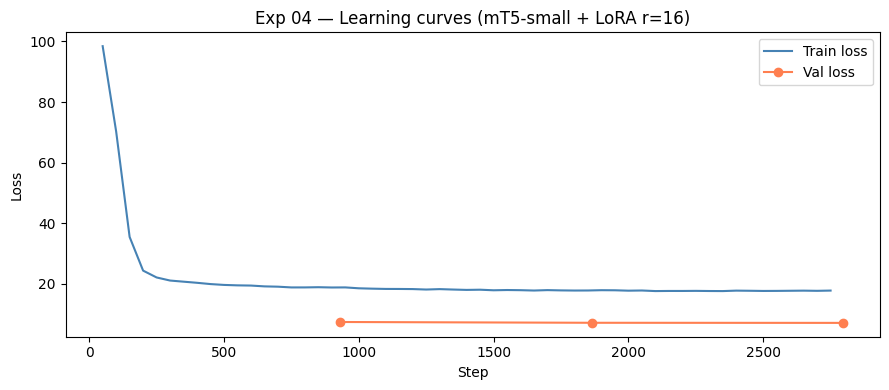

In [12]:
log_history = trainer.state.log_history
train_logs  = [x for x in log_history if 'loss' in x and 'eval_loss' not in x]
eval_logs   = [x for x in log_history if 'eval_loss' in x]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot([x['step'] for x in train_logs], [x['loss'] for x in train_logs],
        label='Train loss', color='steelblue')
ax.plot([x['step'] for x in eval_logs],  [x['eval_loss'] for x in eval_logs],
        label='Val loss', color='coral', marker='o')
ax.set_xlabel('Step')
ax.set_ylabel('Loss')
ax.set_title('Exp 04 — Learning curves (mT5-small + LoRA r=16)')
ax.legend()
plt.tight_layout()
plt.savefig(SAVE_DIR + 'exp04_learning_curve.png', dpi=150)
plt.show()

## Batch generation and ROUGE helpers

In [13]:
_scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=False)

def evaluate_rouge(predictions, references):
    r1s, rls = [], []
    for pred, ref in zip(predictions, references):
        s = _scorer.score(ref, pred)
        r1s.append(s['rouge1'].fmeasure)
        rls.append(s['rougeL'].fmeasure)
    return {
        'rouge1': round(sum(r1s) / len(r1s), 4),
        'rougeL': round(sum(rls) / len(rls), 4),
    }

def generate_batch(prompts, batch_size=8, max_new_tokens=200):
    model.eval()
    predictions = []
    for i in tqdm(range(0, len(prompts), batch_size)):
        batch  = prompts[i : i + batch_size]
        inputs = tokenizer(batch, return_tensors='pt', padding=True,
                            truncation=True, max_length=512).to(model.device)
        with torch.no_grad():
            out = model.generate(**inputs, max_new_tokens=max_new_tokens,
                                  num_beams=4, no_repeat_ngram_size=3, early_stopping=True)
        predictions.extend(tokenizer.batch_decode(out, skip_special_tokens=True))
    return predictions

## Evaluate on full validation set

In [14]:
val_preds  = generate_batch(val_df['prompt_text'].tolist())
val_scores = evaluate_rouge(val_preds, val_df['output_clean'].tolist())

print(f"ROUGE-1 F1 : {val_scores['rouge1']}")
print(f"ROUGE-L F1 : {val_scores['rougeL']}")
print(f"Est. LB    : {0.37*val_scores['rouge1'] + 0.37*val_scores['rougeL']:.4f}")

  0%|          | 0/836 [00:00<?, ?it/s]

ROUGE-1 F1 : 0.1724
ROUGE-L F1 : 0.1385
Est. LB    : 0.1150


## Per-language ROUGE breakdown

In [15]:
rows = []
for pred, ref, lang in zip(val_preds, val_df['output_clean'], val_df['language']):
    s = _scorer.score(ref, pred)
    rows.append({'language': lang, 'rouge1': s['rouge1'].fmeasure, 'rougeL': s['rougeL'].fmeasure})

summary = (
    pd.DataFrame(rows)
    .groupby('language')
    .agg(rouge1=('rouge1', 'mean'), rougeL=('rougeL', 'mean'), count=('rouge1', 'count'))
    .round(4)
    .reset_index()
    .sort_values('rougeL', ascending=False)
)
print(summary.to_string(index=False))

language  rouge1  rougeL  count
    Akan  0.2709  0.1986   1114
 Eng_Eth  0.2098  0.1859    564
 English  0.1714  0.1400   3182
 Swahili  0.1572  0.1288    518
 Luganda  0.1204  0.0989    846
 Amharic  0.0089  0.0089    462


## Generate test submission

In [16]:
test_preds = generate_batch(test_df['prompt_text'].tolist())

submission = pd.DataFrame({
    'ID':         test_df['ID'].values,
    'TargetRLF1': test_preds,
    'TargetR1F1': test_preds,
    'TargetLLM':  test_preds,
})

out_path = SAVE_DIR + 'exp04_mt5small_lora_r16.csv'
submission.to_csv(out_path, index=False)
print(f'Saved: {out_path}')
submission.head(3)

  0%|          | 0/328 [00:00<?, ?it/s]

Saved: /kaggle/working/outputs/exp04_mt5small_lora_r16.csv


,ID,TargetRLF1,TargetR1F1,TargetLLM
0,ID_TS_Aka_Gha_A3B1799D,"<extra_id_0> a wɔde nkyerɛkyerɛ nneɛma, adwuma...","<extra_id_0> a wɔde nkyerɛkyerɛ nneɛma, adwuma...","<extra_id_0> a wɔde nkyerɛkyerɛ nneɛma, adwuma..."
1,ID_TS_Aka_Gha_1C80317F,<extra_id_0> a wɔnya nipadua mu ahofadi wɔ nna...,<extra_id_0> a wɔnya nipadua mu ahofadi wɔ nna...,<extra_id_0> a wɔnya nipadua mu ahofadi wɔ nna...
2,ID_TS_Aka_Gha_06671AD1,<extra_id_0> na mmabun bɛtumi afa so ehunu nsu...,<extra_id_0> na mmabun bɛtumi afa so ehunu nsu...,<extra_id_0> na mmabun bɛtumi afa so ehunu nsu...


## Results

Final results across all experiments (leaderboard and validation metrics). This experiment is **Exp 04**.

| Exp | Model | Key change | Decoding | Zindi LB | ROUGE-1 | ROUGE-L | LLM-Judge |
|-----|-------|-----------|----------|----------|---------|---------|-----------|
| Exp 01 | mt5-small | zero-shot baseline | greedy | 0.0017 | 0.0001 | 0.0001 | — |
| Exp 03 | mt5-small | LoRA r=8, attention (q,v) | greedy | — | — | — | — |
| Exp 04 | mt5-small | LoRA r=16, attention (q,v) | greedy | 0.1218 | 0.1839 | 0.1453 | 0.0 |
| Exp 05 | mt5-small | LoRA full attention + FFN | greedy | 0.1598 | 0.1713 | 0.1380 | 0.1746 |
| Exp 06 | mt5-base | scaled model, full targets | greedy | 0.1811 | 0.2077 | 0.1668 | 0.1638 |
| Exp 07 | mt5-base | beam search (num_beams=4) | beam=4 | 0.2536 | 0.2530 | 0.1811 | 0.3576 |
| Exp 08 | mt5-base | 5 epochs (champion) | beam=4 | 0.2613 | 0.2760 | 0.1923 | 0.3384 |
| Exp 09 | mt5-base | LoRA r=32 | beam=4 | 0.2554 | 0.2678 | 0.1879 | 0.3337 |
| Exp 10 | mt5-base | richer prompt + length_penalty | beam=4 | not submitted | — | — | — |
| Exp 11 | mt5-base | lower LR 2e-4 + warmup | beam=4 | not submitted | — | — | — |

**Insight.** Doubling the LoRA rank from 8 to 16 produced the first strong leaderboard score (0.1218) with high ROUGE-1 (0.1839), showing the model captures relevant keywords. However the LLM-Judge score is 0.0: the answers overlap on vocabulary but are not fluent or complete enough to be judged usable. This gap between lexical overlap and judged quality is the central problem the next experiment targets.